In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

2026-05-07 09:50:00.959815: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778147401.210342      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778147401.278323      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778147401.901867      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778147401.901926      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778147401.901930      57 computation_placer.cc:177] computation placer alr

In [2]:
train_path = "/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images"
test_path = "/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/images"

In [3]:
img_size = 128
batch_size = 16

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [5]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [6]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=False,
    class_mode='categorical'
)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


In [7]:
print(train_data.class_indices)
print(test_data.class_indices)

{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [8]:

base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128,activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(6,activation='softmax')(x)

model = Model(inputs=base_model.input,outputs=output)


2026-05-07 09:50:38.601294: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [11]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

In [12]:
checkpoint = ModelCheckpoint(
    "best_inception_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [13]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=[early_stop,reduce_lr,checkpoint]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 52s 475ms/step - accuracy: 0.2626 - loss: 2.0894 - val_accuracy: 0.6333 - val_loss: 1.1321 - learning_rate: 1.0000e-04
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 335ms/step - accuracy: 0.5693 - loss: 1.1249 - val_accuracy: 0.8028 - val_loss: 0.7627 - learning_rate: 1.0000e-04
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 341ms/step - accuracy: 0.7401 - loss: 0.8090 - val_accuracy: 0.8222 - val_loss: 0.6263 - learning_rate: 1.0000e-04
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 339ms/step - accuracy: 0.7872 - loss: 0.6345 - val_accuracy: 0.8500 - val_loss: 0.5229 - learning_rate: 1.0000e-04
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 338ms/step - accuracy: 0.8307 - loss: 0.5008 - val_accuracy: 0.8611 - val_loss: 0.4706 - learning_rate: 1.0000e-04
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 29s 327ms/step - accuracy: 0.8607 - loss: 0.4316 - val_accuracy: 0.8611 - val_loss: 0.4310 - learning_rate: 1.0000e-04
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 340ms/step - acc

In [14]:
model = tf.keras.models.load_model(
    "best_inception_model.keras"
)


In [15]:
loss,accuracy = model.evaluate(test_data)

print("Test Accuracy :",accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 233ms/step - accuracy: 0.9351 - loss: 0.2060
Test Accuracy : 0.9388889074325562


In [16]:
pred = model.predict(test_data)

pred_classes = np.argmax(pred,axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 336ms/step


In [17]:
print(classification_report(
    test_data.classes,
    pred_classes
))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        60
           1       0.98      0.83      0.90        60
           2       0.97      1.00      0.98        60
           3       0.86      0.95      0.90        60
           4       0.90      0.95      0.93        60
           5       0.98      0.93      0.96        60

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



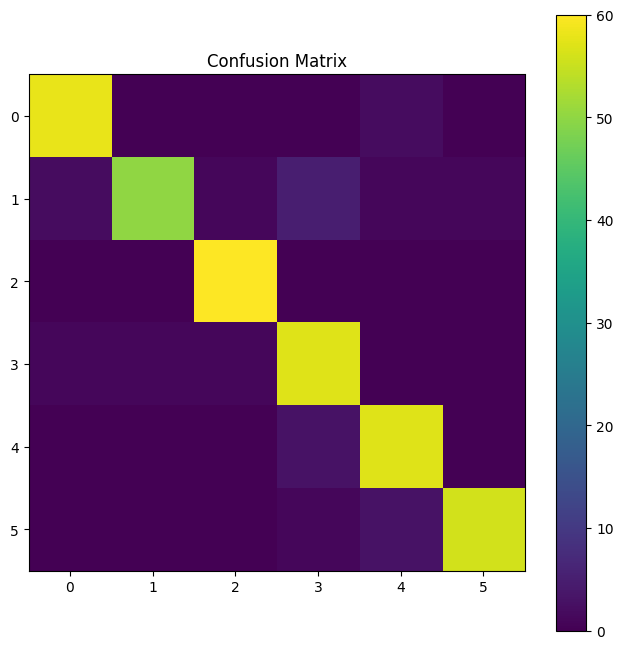

In [19]:
cm = confusion_matrix(
    test_data.classes,
    pred_classes
)
plt.figure(figsize=(8,8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

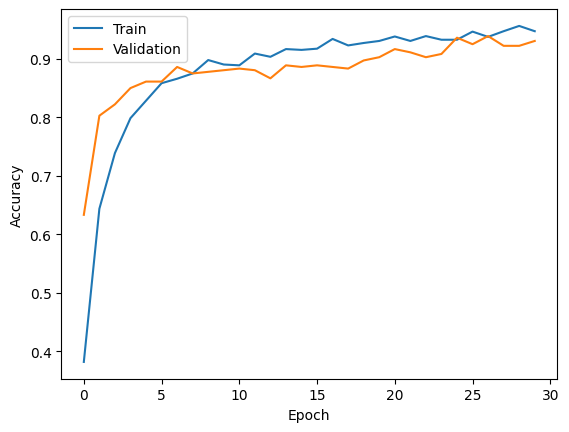

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

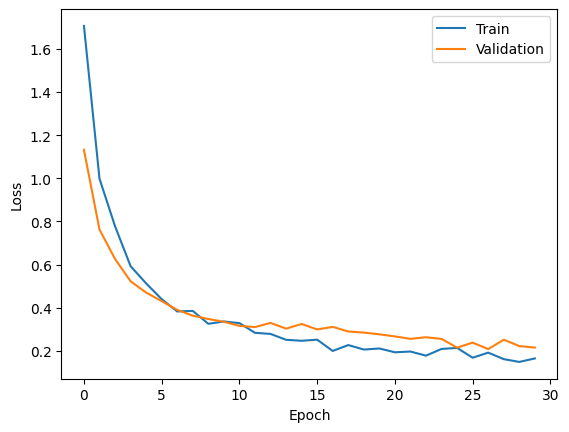

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()